In [1]:
import math
import random
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def theoretical_metrics(lam, mu, m):
    rho = lam / mu
    k = m + 1
    if abs(rho - 1) < 1e-12:
        p0 = 1 / (k + 1)
        probs = [p0] * (k + 1)
    else:
        p0 = (1 - rho) / (1 - rho ** (k + 1))
        probs = [p0 * rho ** n for n in range(k + 1)]
    p_loss = probs[-1]
    l = sum(n * probs[n] for n in range(k + 1))
    lq = sum(max(0, n - 1) * probs[n] for n in range(k + 1))
    lam_eff = lam * (1 - p_loss)
    wq = lq / lam_eff if lam_eff > 0 else 0
    ws = l / lam_eff if lam_eff > 0 else 0
    load = 1 - probs[0]
    return {
        "P_loss": p_loss,
        "Lq": lq,
        "Wq": wq,
        "Ws": ws,
        "Load": load,
        "lambda_eff": lam_eff
    }

In [3]:
def simulate_mm1m(lam, mu, m, t_max=1000, seed=42):
    rng = random.Random(seed)
    t = 0.0
    n = 0
    next_arrival = rng.expovariate(lam)
    next_departure = float("inf")
    arrivals = 0
    accepted = 0
    lost = 0
    served = 0
    area_q = 0.0
    busy_time = 0.0
    total_wait = 0.0
    total_system = 0.0
    queue = []
    current_service_arrival = None

    while True:
        t_next = min(next_arrival, next_departure, t_max)
        dt = t_next - t
        area_q += max(0, n - 1) * dt
        if n > 0:
            busy_time += dt
        t = t_next

        if t >= t_max:
            break

        if next_arrival <= next_departure:
            arrivals += 1
            if n < m + 1:
                accepted += 1
                if n == 0:
                    current_service_arrival = t
                    next_departure = t + rng.expovariate(mu)
                else:
                    queue.append(t)
                n += 1
            else:
                lost += 1
            next_arrival = t + rng.expovariate(lam)
        else:
            served += 1
            n -= 1
            total_system += t - current_service_arrival
            if n > 0:
                arrival_time = queue.pop(0)
                total_wait += t - arrival_time
                current_service_arrival = arrival_time
                next_departure = t + rng.expovariate(mu)
            else:
                current_service_arrival = None
                next_departure = float("inf")

    p_loss = lost / arrivals if arrivals else 0
    lq = area_q / t_max
    wq = total_wait / accepted if accepted else 0
    ws = total_system / served if served else 0
    load = busy_time / t_max

    return {
        "arrivals": arrivals,
        "accepted": accepted,
        "lost": lost,
        "served": served,
        "P_loss": p_loss,
        "Lq": lq,
        "Wq": wq,
        "Ws": ws,
        "Load": load
    }

In [4]:
lam = 10
mu = 1
m = 5

simulation = simulate_mm1m(lam, mu, m, t_max=1000, seed=42)
theory = theoretical_metrics(lam, mu, m)

base_result = pd.DataFrame({
    "Показатель": ["Прибыло", "Принято", "Потеряно", "P потерь", "Lq", "Wq", "Ws", "Загрузка"],
    "Эксперимент": [
        simulation["arrivals"],
        simulation["accepted"],
        simulation["lost"],
        simulation["P_loss"],
        simulation["Lq"],
        simulation["Wq"],
        simulation["Ws"],
        simulation["Load"]
    ],
    "Теория": [
        lam * 1000,
        theory["lambda_eff"] * 1000,
        (lam - theory["lambda_eff"]) * 1000,
        theory["P_loss"],
        theory["Lq"],
        theory["Wq"],
        theory["Ws"],
        theory["Load"]
    ]
})
base_result

,Показатель,Эксперимент,Теория
0,Прибыло,10003.000000,10000.000000
1,Принято,1040.000000,999.999100
2,Потеряно,8963.000000,9000.000900
3,P потерь,0.896031,0.900000
4,Lq,4.880168,4.888890
5,Wq,4.677890,4.888895
6,Ws,5.666316,5.888895
7,Загрузка,0.999891,0.999999


In [5]:
m_values = list(range(1, 11))
rows = []

for current_m in m_values:
    sim = simulate_mm1m(10, 1, current_m, t_max=1000, seed=100 + current_m)
    th = theoretical_metrics(10, 1, current_m)
    rows.append([
        current_m,
        sim["P_loss"], th["P_loss"],
        sim["Lq"], th["Lq"],
        sim["Wq"], th["Wq"],
        sim["Ws"], th["Ws"],
        sim["Load"], th["Load"]
    ])

table_m = pd.DataFrame(rows, columns=[
    "m",
    "P_loss_exp", "P_loss_theor",
    "Lq_exp", "Lq_theor",
    "Wq_exp", "Wq_theor",
    "Ws_exp", "Ws_theor",
    "Load_exp", "Load_theor"
])
table_m

,m,P_loss_exp,P_loss_theor,Lq_exp,Lq_theor,Wq_exp,Wq_theor,Ws_exp,Ws_theor,Load_exp,Load_theor
0,1,0.905557,0.900901,0.909095,0.900901,0.961949,0.909091,2.015136,1.909091,0.993771,0.990991
1,2,0.900487,0.900090,1.893134,1.890189,1.886717,1.891892,2.891015,2.891892,0.999080,0.999100
2,3,0.903582,0.900009,2.886213,2.889029,2.973971,2.889289,4.019374,3.889289,0.999613,0.999910
3,4,0.907016,0.900001,3.901094,3.888904,4.123979,3.888939,5.205797,4.888939,0.999678,0.999991
4,5,0.897610,0.900000,4.880911,4.888890,4.730908,4.888895,5.730927,5.888895,0.999790,0.999999
5,6,0.904352,0.900000,5.895960,5.888889,6.155702,5.888890,7.250637,6.888890,0.999876,1.000000
6,7,0.898701,0.900000,6.883613,6.888889,6.661905,6.888889,7.685569,7.888889,0.999972,1.000000
7,8,0.900335,0.900000,7.890954,7.888889,7.981744,7.888889,9.072068,8.888889,0.999986,1.000000
8,9,0.897301,0.900000,8.877081,8.888889,8.722827,8.888889,9.800174,9.888889,0.999967,1.000000
9,10,0.901643,0.900000,9.879696,9.888889,10.057970,9.888889,11.194243,10.888889,0.999728,1.000000


In [6]:
mu_values = list(range(1, 15))
rows = []

for current_mu in mu_values:
    sim = simulate_mm1m(10, current_mu, 5, t_max=1000, seed=200 + current_mu)
    th = theoretical_metrics(10, current_mu, 5)
    rows.append([
        current_mu,
        sim["P_loss"], th["P_loss"],
        sim["Lq"], th["Lq"],
        sim["Wq"], th["Wq"],
        sim["Ws"], th["Ws"],
        sim["Load"], th["Load"]
    ])

table_mu = pd.DataFrame(rows, columns=[
    "mu",
    "P_loss_exp", "P_loss_theor",
    "Lq_exp", "Lq_theor",
    "Wq_exp", "Wq_theor",
    "Ws_exp", "Ws_theor",
    "Load_exp", "Load_theor"
])
table_mu

,mu,P_loss_exp,P_loss_theor,Lq_exp,Lq_theor,Wq_exp,Wq_theor,Ws_exp,Ws_theor,Load_exp,Load_theor
0,1,0.898506,0.900000,4.889043,4.888890,4.750572,4.888895,5.754180,5.888895,0.999993,0.999999
1,2,0.806083,0.800010,4.754193,4.750141,2.475201,2.375192,3.000851,2.875192,0.999856,0.999949
2,3,0.709611,0.700153,4.578907,4.573470,1.552702,1.525269,1.895159,1.858602,0.999423,0.999490
3,4,0.605042,0.600985,4.388166,4.347283,1.097080,1.089503,1.348415,1.339503,0.997979,0.997538
4,5,0.507530,0.503937,4.075015,4.062992,0.830785,0.819048,1.033565,1.019048,0.991635,0.992126
5,6,0.412844,0.411520,3.665752,3.720799,0.628663,0.632273,0.797118,0.798939,0.977942,0.980800
6,7,0.333200,0.326924,3.317990,3.333345,0.497734,0.495240,0.641483,0.638097,0.954424,0.961538
7,8,0.257580,0.253073,2.956521,2.923908,0.400895,0.391458,0.527583,0.516458,0.931456,0.933658
8,9,0.199980,0.191680,2.562140,2.519460,0.317686,0.311691,0.429045,0.422802,0.898110,0.898133
9,10,0.146180,0.142857,2.129776,2.142857,0.250091,0.250000,0.350300,0.350000,0.853375,0.857143


In [7]:
eligible_m = table_m.loc[table_m["P_loss_theor"] <= 0.05, "m"]
optimal_m = None if eligible_m.empty else int(eligible_m.iloc[0])
optimal_m

In [8]:
optimal_mu = int(table_mu.loc[table_mu["P_loss_theor"] <= 0.05, "mu"].iloc[0])
optimal_mu

14

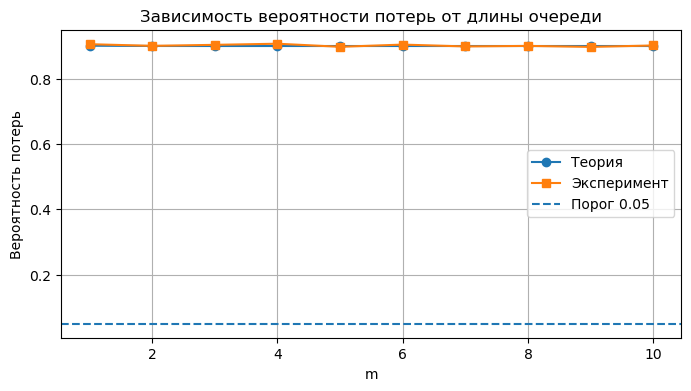

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(table_m["m"], table_m["P_loss_theor"], marker="o", label="Теория")
plt.plot(table_m["m"], table_m["P_loss_exp"], marker="s", label="Эксперимент")
plt.axhline(0.05, linestyle="--", label="Порог 0.05")
plt.xlabel("m")
plt.ylabel("Вероятность потерь")
plt.title("Зависимость вероятности потерь от длины очереди")
plt.grid(True)
plt.legend()
plt.show()

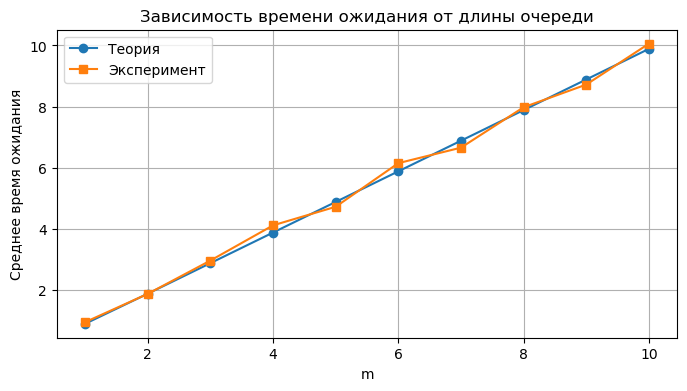

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(table_m["m"], table_m["Wq_theor"], marker="o", label="Теория")
plt.plot(table_m["m"], table_m["Wq_exp"], marker="s", label="Эксперимент")
plt.xlabel("m")
plt.ylabel("Среднее время ожидания")
plt.title("Зависимость времени ожидания от длины очереди")
plt.grid(True)
plt.legend()
plt.show()

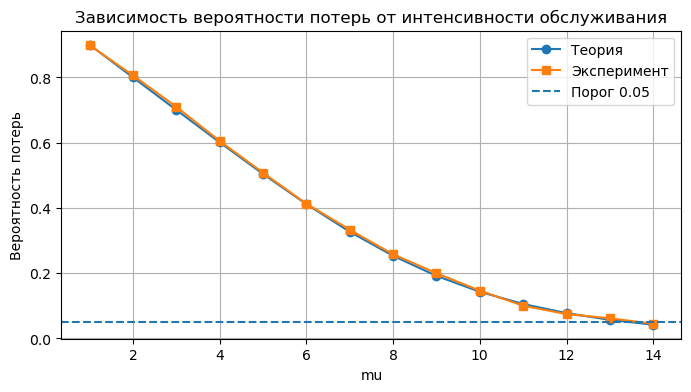

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(table_mu["mu"], table_mu["P_loss_theor"], marker="o", label="Теория")
plt.plot(table_mu["mu"], table_mu["P_loss_exp"], marker="s", label="Эксперимент")
plt.axhline(0.05, linestyle="--", label="Порог 0.05")
plt.xlabel("mu")
plt.ylabel("Вероятность потерь")
plt.title("Зависимость вероятности потерь от интенсивности обслуживания")
plt.grid(True)
plt.legend()
plt.show()

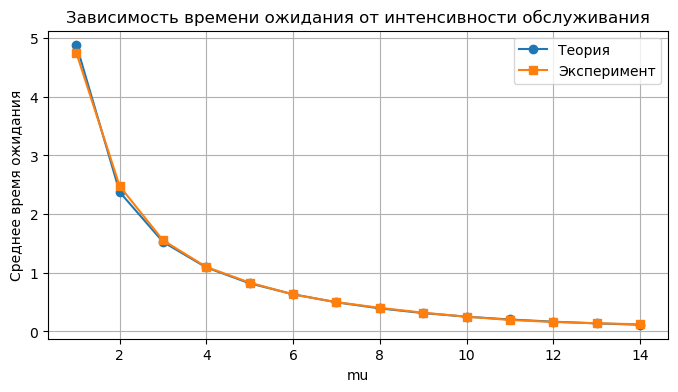

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(table_mu["mu"], table_mu["Wq_theor"], marker="o", label="Теория")
plt.plot(table_mu["mu"], table_mu["Wq_exp"], marker="s", label="Эксперимент")
plt.xlabel("mu")
plt.ylabel("Среднее время ожидания")
plt.title("Зависимость времени ожидания от интенсивности обслуживания")
plt.grid(True)
plt.legend()
plt.show()